(20631, 26)
(185, 23)
[[2.73100853e-04 0.00000000e+00 0.00000000e+00 5.00850001e-01
  5.70216721e+00 8.80836918e+00 0.00000000e+00 1.03411494e-03
  8.84733015e-01 7.24960189e-02 3.93284084e+00 0.00000000e+00
  2.72992293e-01 7.60353568e-01 7.04389659e-02 4.15269634e+00
  3.77476557e-02 0.00000000e+00 1.47235544e+00 0.00000000e+00
  0.00000000e+00 1.67349151e-01 1.06117440e-01]]


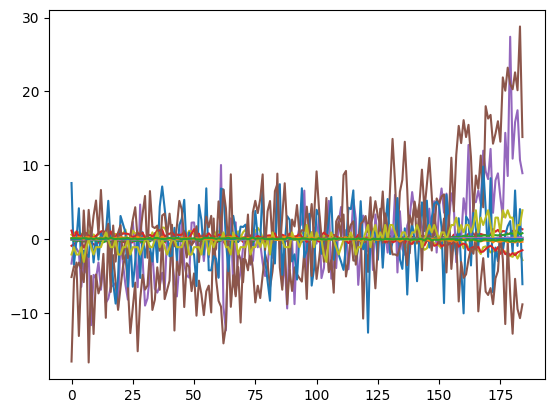

In [1]:
# Load data
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

data = np.loadtxt("train_FD001.txt") # DOWNLOAD THE DATA FROM THE LINK IN THE PAPER
print(data.shape)

xs = []
starting_points = np.where(data[:, 1] == 1.0)[0]
for i in range(0, len(starting_points) - 1):
    x = data[
        starting_points[i]:starting_points[i+1],
        3:
    ]

    x -= np.mean(x, axis=0, keepdims=True)
    # x = (x / np.std(x, axis=0, keepdims=True))[:, np.std(x, axis=0) > 0]

    x = x[:, np.all(np.isfinite(x), axis=0)]

    xs.append(x)

print(x.shape)
plt.plot(x)
print(np.std(x, axis=0, keepdims=True))

In [2]:
from rhythmic_sharing import RhythmicNetwork

from tqdm import tqdm
import numpy as np

best_mse = np.inf

for sr in tqdm(np.linspace(0.2, 0.8, 10)):
    for iw in np.linspace(0.25, 1.0, 10):
        for l in np.linspace(0.5, 0.95, 10):
            network = RhythmicNetwork(
                # Tune Rhythmic Sharing
                dt=10,
                input_dims=x.shape[1],
                spectral_radius=sr,
                input_weight=iw,
                average_degree_nodes=8,
                num_nodes=512, # 256
                leakage=l,
                # Rhythmic params
                link_strength_change_ratio=0
            )

            network.train(x.T[:, :-100])
            pred = network.predict(x.T[:, -110:], warmup_time=10)
            mse = np.mean(np.square((pred[:, 1:] - x.T[:, -100:]))) # /np.std(pred[:, 1:], axis=1, keepdims=True)))
            if mse > 100_000_000:
                network.lsqrs = not network.lsqrs
            
            if mse < best_mse:
                print("New best %.10f" % mse, (sr, iw, l))
                best_esn_param = (sr, iw, l)
                best_mse = mse

  0%|                                                                                           | 0/10 [00:04<?, ?it/s]


KeyboardInterrupt: 

 30%|████████████████████████▌                                                         | 3/10 [16:30<38:33, 330.53s/it]

New best 0.0044268974 (np.float64(0.25), np.float64(0.016666666666666663), np.float64(0.37777777777777777), np.float64(0.01))


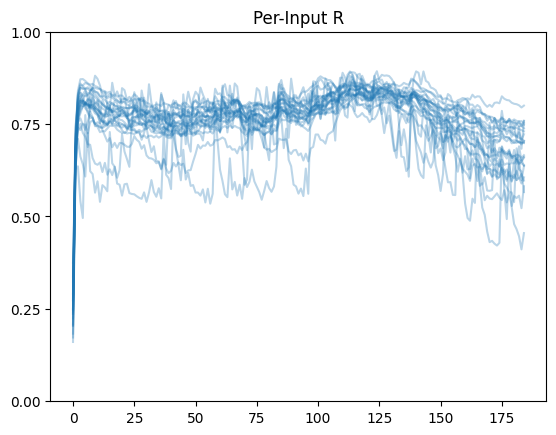

 40%|████████████████████████████████▊                                                 | 4/10 [21:49<32:36, 326.16s/it]

New best 0.0120603460 (np.float64(0.25), np.float64(0.005555555555555557), np.float64(0.37777777777777777), np.float64(0.01))


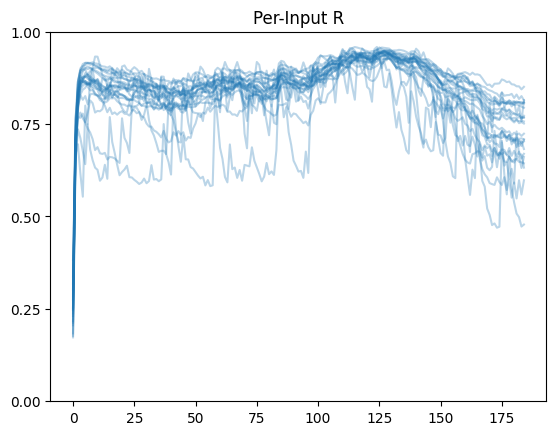

 70%|█████████████████████████████████████████████████████████▍                        | 7/10 [37:44<16:01, 320.50s/it]

New best 0.0169532765 (np.float64(0.25), np.float64(-0.02777777777777778), np.float64(0.45555555555555555), np.float64(0.01))


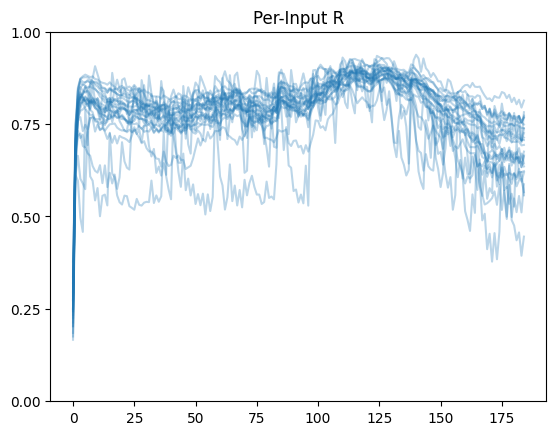

 80%|█████████████████████████████████████████████████████████████████▌                | 8/10 [43:03<10:39, 319.83s/it]

New best 0.0207178961 (np.float64(0.25), np.float64(-0.03888888888888889), np.float64(0.45555555555555555), np.float64(0.01))


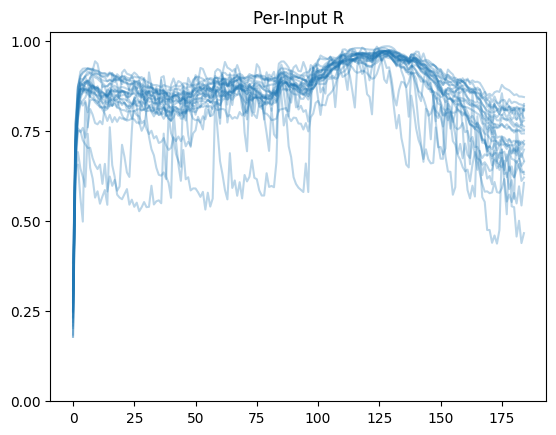

100%|█████████████████████████████████████████████████████████████████████████████████| 10/10 [53:07<00:00, 318.80s/it]


In [3]:
best_difference = 0
for lsr in np.linspace(0.25, 1, 10):
    for e1 in tqdm(np.linspace(-0.05, 0.05, 10)[::-1]): # tqdm(np.linspace(-0.1, -0.0, 10)[::-1]):
        for o in np.linspace(0.01, 0.4, 10):
            for e2 in np.linspace(0.3, 1.0, 10):
                network = RhythmicNetwork(
                    # Tune Rhythmic Sharing
                    dt=10,
                    input_dims=x.shape[1],
                    spectral_radius=best_esn_param[0],
                    input_weight=best_esn_param[1],
                    average_degree_nodes=8,
                    num_nodes=512, #256,
                    leakage=best_esn_param[2],
                    # Rhythmic params
                    link_strength_change_ratio=lsr,
                    omega0=o,
                    epsilon1=e1,
                    epsilon2=e2,
                )

                network.train(x.T, warmup_time=0)
                r = network.get_global_parameters()[0]
                sixty_per = int(len(r) * 0.6)
    
                diff = np.std(r[sixty_per:]) - np.std(r[:sixty_per]) #/np.mean(r.T[:250])
                
                if diff > best_difference and np.mean(r.T[:sixty_per]) > 0.5: # np.mean(network.get_input_parameters()[0].T[75:100, 11]) > 0.5: # and np.mean(network.get_input_parameters()[0].T[75:100, 15]) > 0.5:
                    print("New best %.10f" % diff, (lsr, e1, e2, o))
                    best_param_rhy = (lsr, e1, e2, o)
                    best_difference = diff
    
                    plt.title("Per-Input R")
                    plt.plot(network.get_input_parameters()[0].T, color="tab:blue", alpha=0.3)
                    plt.yticks([0, 0.25, 0.5, 0.75, 1])
                    plt.show()

In [3]:
best_esn_param = (0.8, 0.83, 0.65) # best_esn_param = (0.8, 0.75, 0.5) # best_esn_param = (0.8, 1, 0.5)
best_param_rhy = (0.25, -0.04, 0.46, 0.01) # best_param_rhy = (0.75, -0.18, 0.76, 0.31)

In [4]:
# Run all datasets through detector

global_rs = []
input_rs = []
num_chan = x.shape[1]

for x in tqdm(xs):
    network = RhythmicNetwork(
        # Tune Rhythmic Sharing
        dt=10,
        input_dims=x.shape[1],
        spectral_radius=best_esn_param[0],
        input_weight=best_esn_param[1],
        average_degree_nodes=8,
        num_nodes=512,
        leakage=best_esn_param[2],
        # Rhythmic params
        link_strength_change_ratio=best_param_rhy[0],
        omega0=best_param_rhy[3],
        epsilon1=best_param_rhy[1],
        epsilon2=best_param_rhy[2],
    )
    
    network.train(x.T, warmup_time=0)
    global_rs.append(network.get_global_parameters()[0])
    input_rs.append(network.get_input_parameters()[0])

print(len(xs), len(input_rs))

 71%|█████████████████████████████████████████████████████████▉                        | 70/99 [13:27<05:34, 11.54s/it]


KeyboardInterrupt: 

In [7]:
from drift_helpers.mmdagg import mmdagg

# MMDAgg-based Drift Detector (pseudocode)
# Works like river: you call update(x_t) per timestep.

class MMDAggDriftDetector:
    def __init__(self, window_size=32, step_size=1, alpha=0.001):
        self.reference_buffer = []
        self.test_buffer = []
        self.window_size = window_size
        self.step_size = step_size
        self.alpha = alpha
        self.drift_detected = False
        self.num_samples_seen = 0

    def update(self, x_t):
        """
        x_t : np.ndarray (shape = [n_channels]) or list
        """
        self.num_samples_seen += 1
        self.test_buffer.append(x_t)

        # When test window full, run drift test
        if len(self.test_buffer) >= self.window_size:
            if len(self.reference_buffer) >= self.window_size:

                # Run MMDAgg two-sample test
                self.drift_detected = mmdagg(np.asarray(self.reference_buffer), np.asarray(self.test_buffer), alpha=self.alpha) == 1
                if self.drift_detected:
                    self._on_drift()
                    
            # Slide windows
            self.reference_buffer = (
                self.reference_buffer[-self.window_size:] + self.test_buffer[:self.step_size]
            )
            self.test_buffer = self.test_buffer[self.step_size:]

        return self.drift_detected

    def _on_drift(self):
        # Reset reference window to post-drift data (optional)
        self.reference_buffer = self.test_buffer.copy()
        self.test_buffer = []
        # Optionally log or emit signal
        # print(f"Drift detected at t={self.num_samples_seen}")

0it [00:00, ?it/s]

0.00075


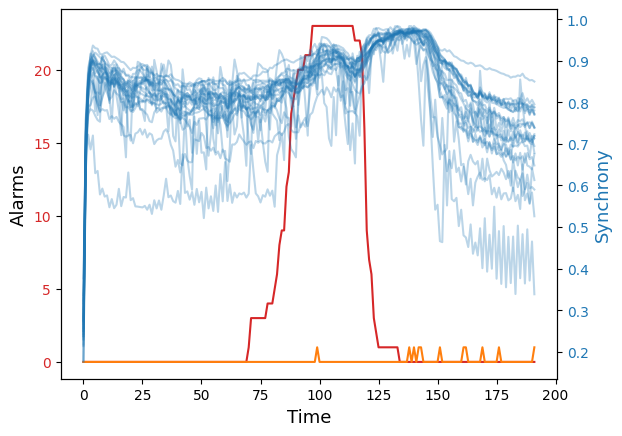

1it [00:06,  6.27s/it]

[ 0.  0.  0.  3.  6.  7.  8.  8.  9. 11. 11. 11. 12. 13. 13. 13. 13. 14.
 15. 16. 19. 22. 22.]
0.00075


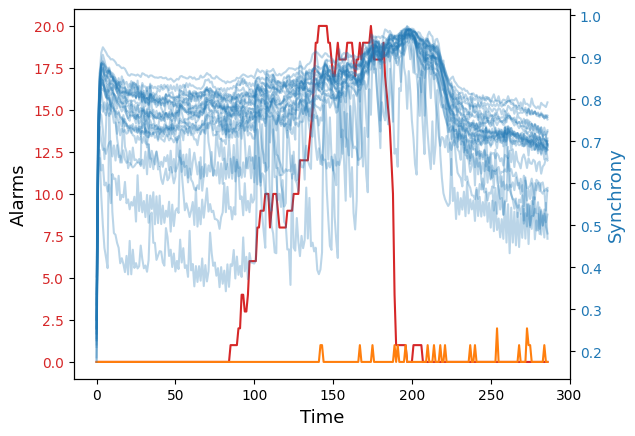

2it [00:16,  8.49s/it]

[10. 15. 17. 17. 22. 22. 27. 27. 29. 32. nan nan nan nan nan nan nan nan
 nan nan nan nan nan]
0.00075


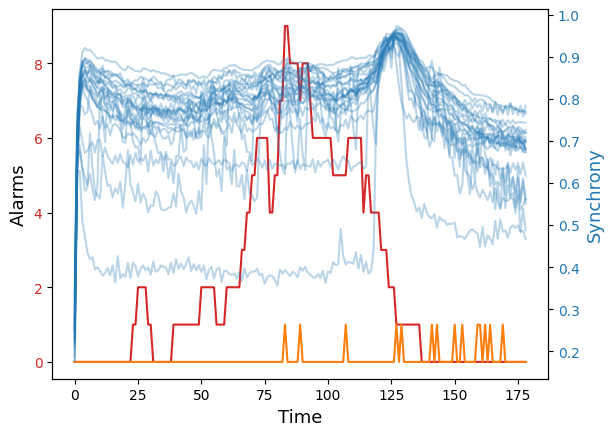

3it [00:21,  7.00s/it]

[ 0.  0.  0.  0.  0.  0.  6.  8.  8. nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan]
0.00075


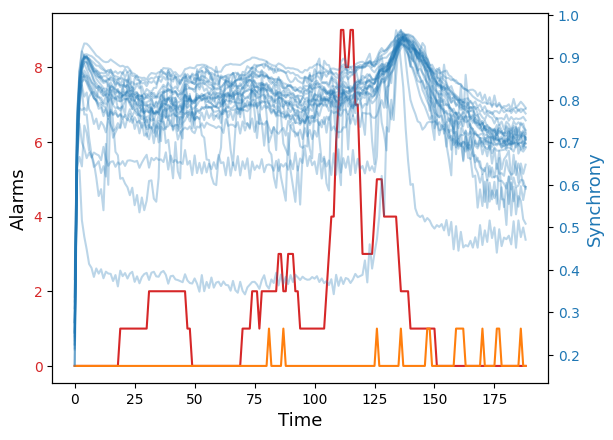

4it [00:27,  6.53s/it]

[ 0.  0. 10. 32. 34. 34. 35. 36. 36. nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan]
0.00075


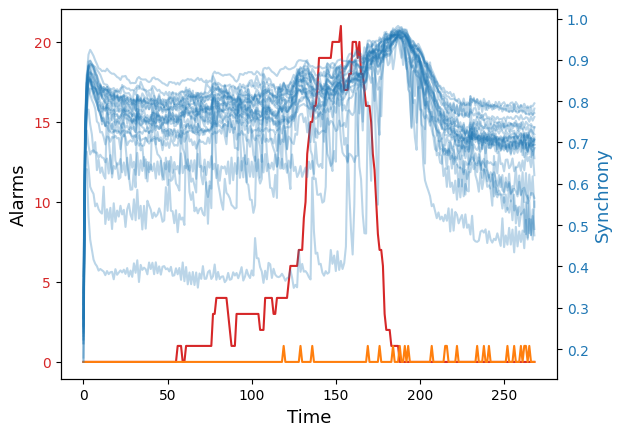

5it [00:35,  7.24s/it]

[ 0.  2.  2.  4. 47. 48. nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan]
0.00075


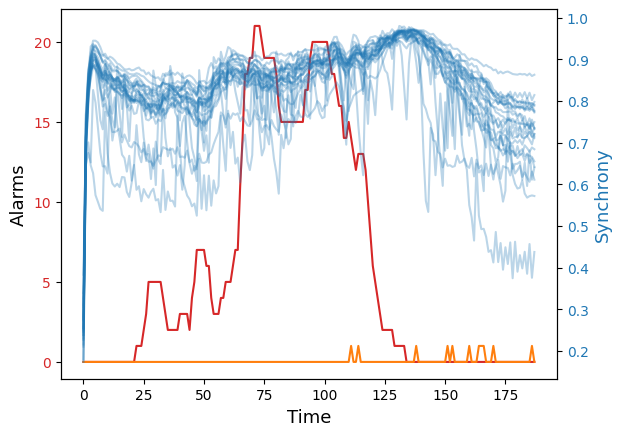

6it [00:41,  6.84s/it]

[ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0. 20. nan nan nan]
0.00075


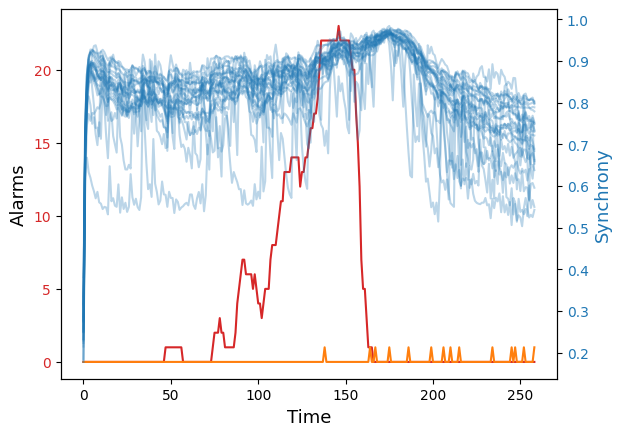

7it [00:50,  7.35s/it]

[ 0.  0.  3. 13. 14. 15. 16. 33. 36. 37. 38. 40. 40. 44. nan nan nan nan
 nan nan nan nan nan]
0.00075


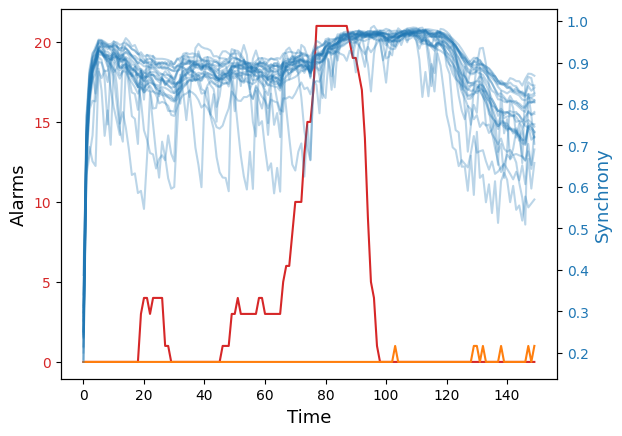

8it [00:54,  6.35s/it]

[ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  1.  1.  2.
  2.  2.  2. nan nan]
0.00075


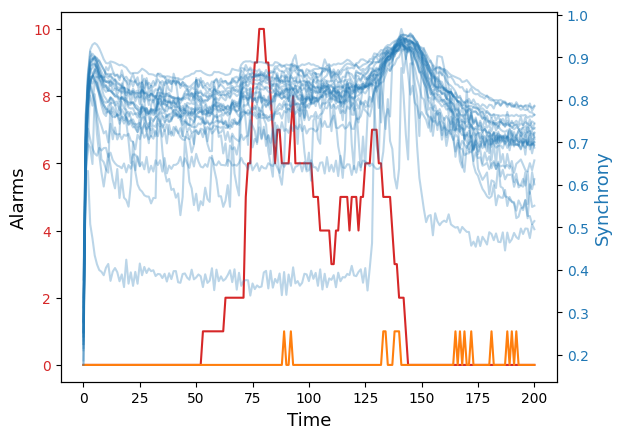

9it [01:00,  6.22s/it]

[ 0.  0.  0.  0.  0.  0.  0.  0.  1.  3. nan nan nan nan nan nan nan nan
 nan nan nan nan nan]
0.00075


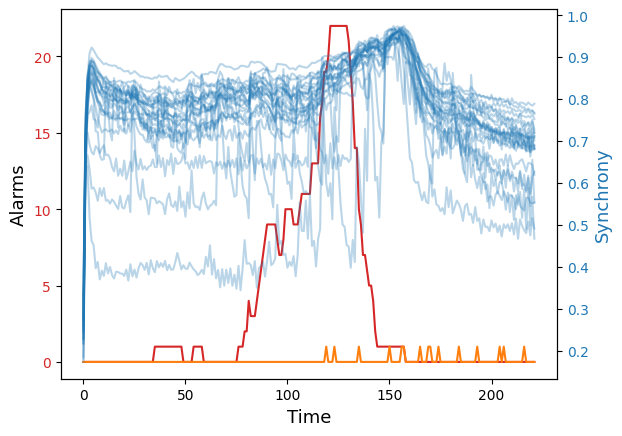

10it [01:06,  6.23s/it]

[ 1.  4.  6.  6. 11. 12. 13. 14. 15. 24. 32. 37. 37. 41. 41. 41. 42. 43.
 43. 45. 46. 46. nan]
0.00075


10it [01:14,  7.42s/it]


KeyboardInterrupt: 

In [21]:
# Run tests (including against other algorithms)

from scipy.stats import theilslopes
from scipy.ndimage import median_filter
from river.drift import ADWIN, binary, KSWIN, PageHinkley

def theil_slopes_detection(data, window_size, min_slope=0.15):
    # Shape must be (channels, t,)
    # First filter
    data = median_filter(data, size=window_size * 4, axes=[-1])
    
    expanded_data = np.zeros(data.shape + (window_size,))
    expanded_data[:, :, 0] = data
    for i in range(1, window_size):
        expanded_data[:, :, i] = np.roll(expanded_data[:, :, i-1], -1, axis=-1)
    
    expanded_data = expanded_data[:, :-window_size + 1]
    stds = np.std(expanded_data, axis=-1)
    
    slopes = theilslopes(expanded_data, axis=-1)
    slopes, ub, lb = slopes.slope, slopes.low_slope, slopes.high_slope

    alarms = np.sum(slopes > min_slope, axis=0)
    # alarms = np.sum(np.logical_or(
    #     np.logical_and(slopes > min_slope, lb > min_slope), np.logical_and(slopes < -min_slope, ub < -min_slope)
    # ), axis=0)
    # alarms = calc_river_alarms(KSWIN, slopes)

    return alarms
    

def calc_river_alarms(alg, data):
    drifts = np.zeros((data.shape[1],))

    for chan in range(data.shape[0]):
        if alg is ADWIN: # Add if statement for mmdagg that adds all the channels, not just one
            a = alg(clock=1)
        else:
            a = alg()

        if alg is MMDAggDriftDetector:
            try:
                for t in range(data.shape[1]):
                    a.update(data[:, t])
                    if a.drift_detected:
                        drifts[t] += 1
            except TypeError:
                pass
        else:
            try:
                for t in range(data.shape[1]):
                    a.update(data[chan, t])
                    if a.drift_detected:
                        drifts[t] += 1
            except ValueError:
                pass
            
    return drifts


far_and_first_alarm = np.zeros((3, 6, len(xs), xs[0].shape[1], 3)) # num ruls, num algo, num trials, num cutoffs, far/first alarm/tpr


for i, (x, rs) in tqdm(enumerate(zip(xs, input_rs))):   
    comp_alarms = []
    for comp in [ADWIN, binary.DDM, KSWIN, PageHinkley]: #, MMDAggDriftDetector]: # 
        comp_alarms.append(calc_river_alarms(comp, x.T))
        
    # Try a couple options
    max_ta_over_fa = 0
    alarms = np.zeros(rs.shape[1])
    for j in [0.00075]: # np.logspace(-4, -2, 10):
        temp_alarms = theil_slopes_detection(rs, 20, min_slope=j)
        if np.sum(temp_alarms[:100]) > 0 and np.sum(temp_alarms[-100:])/np.sum(temp_alarms[:100]) > max_ta_over_fa:
            print(j)
            alarms[-temp_alarms.shape[0]:] = temp_alarms
            max_ta_over_fa = np.sum(temp_alarms[-100:])/np.sum(temp_alarms[:100])
        
    fig, ax1 = plt.subplots()
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Alarms')
    ax1.plot(alarms, color="tab:red")
    for comp in [comp_alarms[0]]:
        ax1.plot(comp, color="tab:orange")
    ax1.tick_params(axis='y', labelcolor="tab:red")
    
    ax2 = ax1.twinx()
    ax2.set_ylabel('Synchrony', color="tab:blue")
    ax2.plot(rs.T, color="tab:blue", alpha=0.3)
    ax2.tick_params(axis='y', labelcolor="tab:blue")
    
    plt.show()

    # Compute stats
    for j, rul in enumerate([75, 90, 105]):
        for k, temp_alarms in enumerate([alarms] + comp_alarms):
            for cutoff in range(xs[0].shape[1]):
                false_alarm_rate = np.sum(temp_alarms[:rul] > cutoff)
                first_true_alarm = np.nonzero(temp_alarms[rul:rul+50] > cutoff)[0]
                if len(first_true_alarm) > 0:
                    far_and_first_alarm[j, k, i, cutoff, 0] = false_alarm_rate > 0
                    far_and_first_alarm[j, k, i, cutoff, 1] = np.min(first_true_alarm)
                    far_and_first_alarm[j, k, i, cutoff, 2] = 1
                else:
                    far_and_first_alarm[j, k, i, cutoff, 0] = false_alarm_rate > 0
                    far_and_first_alarm[j, k, i, cutoff, 1] = np.nan
                    far_and_first_alarm[j, k, i, cutoff, 2] = 0
                    
    print(far_and_first_alarm[0, 0, i, :, 1])

# Find best f1 score for each algorithm for each rul
precision = np.nanmean(far_and_first_alarm[:, :, :, :, 2]/(far_and_first_alarm[:, :, :, :, 2] + far_and_first_alarm[:, :, :, :, 0]), axis=2)
recall = np.nanmean(far_and_first_alarm[:, :, :, :, 2], axis=2)

f1 = (2 * precision * recall)/(precision + recall)

for rul in range(3):
    print([75, 90, 105][rul])
    for algo in range(6):
        try:
            best_cutoff = np.nanargmax(np.round(f1[rul, algo], decimals=2), axis=-1)
            print(
                ["Ours", "ADWIN", "DDM", "KSWIN", "PH", "MMD"][algo], best_cutoff,
                f1[rul, algo, best_cutoff], precision[rul, algo, best_cutoff], recall[rul, algo, best_cutoff],
                np.nanmean(far_and_first_alarm[rul, algo, :, best_cutoff, 1])
            )
        except ValueError:
            pass

for rul in range(2):
    print([70, 85, 100][rul])
    for algo in range(6):
        try:
            best_cutoff = np.nanargmin(np.nanmean(far_and_first_alarm[rul, algo, :, :, 1]), axis=-1)
            print(
                ["Ours", "ADWIN", "DDM", "KSWIN", "PH", "MMD"][algo], best_cutoff,
                f1[rul, algo, best_cutoff], precision[rul, algo, best_cutoff], recall[rul, algo, best_cutoff],
                np.nanmean(far_and_first_alarm[rul, algo, :, best_cutoff, 1])
            )
        except ValueError:
            pass


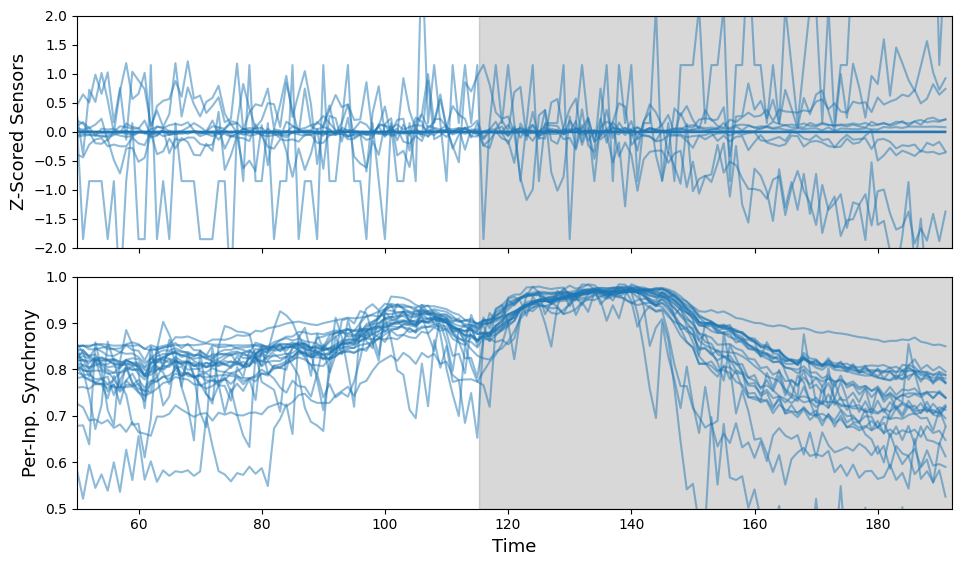

In [29]:
example = 0

SMALL_SIZE = 10
MEDIUM_SIZE = 13
BIGGER_SIZE = 20

plt.rc("font", size=SMALL_SIZE)
plt.rc("axes", titlesize=MEDIUM_SIZE, labelsize=MEDIUM_SIZE)
plt.rc("xtick", labelsize=SMALL_SIZE)
plt.rc("ytick", labelsize=SMALL_SIZE)
plt.rc("legend", fontsize=SMALL_SIZE)
plt.rc("figure", titlesize=BIGGER_SIZE)

# fig, axs = plt.subplots(2, 1, sharex=True, figsize=(6.4 * 1.8, 4.8 * 1))
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(6.4 * 1.5, 4.8 * 1.2))


filtered_raw = xs[example]
filtered_raw = filtered_raw[:, np.all(np.abs(filtered_raw) < 10, axis=0)]
axs[0].plot(filtered_raw, alpha=0.5, color="tab:blue")
axs[0].set_ylabel("Z-Scored Sensors")
axs[0].set_ylim([-2, 2])
axs[0].axvspan(len(xs[example]) * 0.6, len(xs[example]), color="grey", alpha=0.3)
axs[0].set_xlim(50, len(xs[example]))

axs[1].plot(input_rs[example].T, alpha=0.5, color="tab:blue")
axs[1].set_xlabel("Time")
axs[1].set_ylabel("Per-Inp. Synchrony")
axs[1].set_ylim([0.5, 1])
axs[1].axvspan(len(xs[example]) * 0.6, len(xs[example]), color="grey", alpha=0.3)
axs[1].set_xlim(50, len(xs[example]))

# fig.suptitle("Imperceptible Sensor Faults have Large Effects on Synchrony")

plt.tight_layout()
plt.savefig("nasa-sync-amp.pdf")
plt.show()

In [18]:
filtered_raw = xs[example]
filtered_raw = filtered_raw[:, np.any(np.abs(filtered_raw) > 3, axis=0)]

In [9]:
# Run significance tests
from lifelines.fitters.coxph_fitter import CoxPHFitter
import pandas as pd


alg_1, thresh_1 = 0, 4
alg_2, thresh_2 = 4, 0

times_1 = np.nan_to_num(far_and_first_alarm[0, alg_1, :, thresh_1, 1], nan=50)
times_2 = np.nan_to_num(far_and_first_alarm[0, alg_2, :, thresh_2, 1], nan=50)

events_1 = ~np.isnan(far_and_first_alarm[0, alg_1, :, thresh_1, 1])
events_2 = ~np.isnan(far_and_first_alarm[0, alg_2, :, thresh_2, 1])

df = pd.DataFrame({
    'time': np.concatenate([times_1, times_2]),
    'event': np.concatenate([events_1, events_2]),
    'group': np.concatenate([np.ones(len(times_1)), np.zeros(len(times_2))])
})

print(np.nanmean(times_1), np.nanmean(times_2))

cph = CoxPHFitter()
cph.fit(df, duration_col='time', event_col='event', formula="group")
cph.print_summary()

0.0 0.0


ZeroDivisionError: No admissable pairs in the dataset.

In [17]:
import importlib
importlib.reload(added_metrics)

<module 'drift_helpers.added_metrics' from 'F:\\My Drive\\Research\\Losert Lab\\rhythmic_sharing\\src\\drift_helpers\\added_metrics.py'>

In [18]:
# Run driftbench on data
from drift_helpers import added_detectors 
from drift_helpers import added_metrics

from driftbench.drift_detection.detectors import (
    RandomGuessDetector,
    RollingMeanDifferenceDetector,
    RollingMeanStandardDeviationDetector,
    AggregateFeatureAlgorithm,
    SlidingKSWINDetector,
    ClusterDetector,
    AutoencoderDetector,
    MMDDetector,
)
from driftbench.drift_detection.metrics import (
    TemporalAUC,
    SoftTAUC,
    AUC,
)

from river.drift import ADWIN, KSWIN, PageHinkley

detectors = [
    # Detectors from me
    added_detectors.RiverDetector(ADWIN, clock=1, delta=0.002),
    added_detectors.RiverDetector(KSWIN),
    # added_detectors.RiverDetector(PageHinkley),
    # added_detectors.RiverDetectorSingleDetect(MMDAggDriftDetector, window_size=32, step_size=1, alpha=0.001),
    
    # Detectors from driftbench
    AutoencoderDetector(
        hidden_layers=[80, 50, 20, 10, 2],
        retrain_always=True,
        detector=AggregateFeatureAlgorithm(
            agg_feature_func=np.mean,
            algorithm=SlidingKSWINDetector(window_size=20, stat_size=20, offset=10),
        ),
        num_epochs=50,
        batch_size=200,
        lr=0.001,
    ),
    AutoencoderDetector(
        hidden_layers=[80, 50, 20, 10, 2],
        retrain_always=True,
        detector=AggregateFeatureAlgorithm(
            agg_feature_func=np.mean,
            algorithm=SlidingKSWINDetector(window_size=20, stat_size=20, offset=10),
        ),
        num_epochs=100,
        batch_size=200,
        lr=0.0001,
    ),
    AutoencoderDetector(
        hidden_layers=[80, 20, 4],
        retrain_always=True,
        detector=AggregateFeatureAlgorithm(
            agg_feature_func=np.mean,
            algorithm=SlidingKSWINDetector(window_size=20, stat_size=20, offset=10),
        ),
        num_epochs=10,
        batch_size=200,
        lr=0.0001,
    ),
    AutoencoderDetector(
        hidden_layers=[80, 20, 4],
        retrain_always=True,
        detector=MMDDetector(window_size=20, stat_size=20, offset=10),
        num_epochs=10,
        batch_size=200,
        lr=0.0001,
    ),
    MMDDetector(window_size=20, stat_size=20, offset=10),
    MMDDetector(window_size=30, stat_size=30, offset=10),
    MMDDetector(window_size=40, stat_size=40, offset=10),
    # RandomGuessDetector(),
    RollingMeanDifferenceDetector(window_size=20),
    RollingMeanDifferenceDetector(window_size=30),
    RollingMeanDifferenceDetector(window_size=40),
    RollingMeanStandardDeviationDetector(window_size=20),
    ClusterDetector(n_centers=10, method="kmeans"),
    ClusterDetector(n_centers=10, method="gaussian mixture"),
    ClusterDetector(n_centers=5, method="kmeans"),
    ClusterDetector(n_centers=5, method="gaussian mixture")
]

f1_score = added_metrics.F1_Score()
metrics = [
    f1_score,
    added_metrics.Precision(f1_metric_obj=f1_score),
    added_metrics.Recall(f1_metric_obj=f1_score),
    added_metrics.Delay(f1_metric_obj=f1_score),
    added_metrics.EarlyDetect(f1_metric_obj=f1_score),
    added_metrics.Accuracy(f1_metric_obj=f1_score),
    TemporalAUC(rule='step'),
    TemporalAUC(rule='trapez'),
    SoftTAUC(rule='step'),
    AUC(),
]

output = []

for i in tqdm(range(len(xs))):
    for detector in detectors:
        Y = np.zeros((xs[i].shape[0],))
        Y[xs[i].shape[0]//10 * 6:] = 1
        # Y[75:] = 1

        prediction = detector.predict(xs[i])
        r_prediction = detector.predict(input_rs[i].T - np.mean(input_rs[i].T, 0, keepdims=True))

        try:
            output.append({
                "sample": i,
                "detector": detector.name,
                "params": detector.get_hparams(),
                "generic_metrics": {
                    metric.name: metric(prediction, Y) for metric in metrics
                },
                "r_metrics": {
                    metric.name: metric(r_prediction, Y) for metric in metrics
                }
            })

        except ValueError:
            pass
        # print(detector.name, f1_score.chosen)

100%|██████████████████████████████████████████████████████████████████████████████████| 99/99 [13:16<00:00,  8.05s/it]


In [19]:
# Separate f1 scores by detector and whether using RS
separated_output = {}
for result in output:
    params = ",".join("%s:%s" % (k, v) for k, v in result["params"].items())
    separated_output[result["detector"] + "," + params] = separated_output.get(result["detector"] + "," + params, {
        "generic": [],
        "rs": []
    })

    separated_output[result["detector"] + "," + params]["generic"].append(result["generic_metrics"])
    separated_output[result["detector"] + "," + params]["rs"].append(result["r_metrics"])

print(separated_output[result["detector"] + "," + params]["rs"][0].keys())
for k, v in separated_output.items():
    separated_output[k]["metrics"] = {
        "generic" : {
            k: np.nanmean([i[k] for i in v["generic"]]) for k in v["generic"][0].keys()
        },
        "rs" : {
            k: np.nanmean([i[k] for i in v["rs"]]) for k in v["rs"][0].keys()
        }
    }
    print(k)
    print(separated_output[k]["metrics"])
    print("====================================")

dict_keys(['F1_Score', 'Precision', 'Recall', 'Delay', 'EarlyDetect', 'Accuracy', 'TAUC-step', 'TAUC-trapez', 'SoftTAUC', 'AUC'])
ADWIN,clock:1,delta:0.002
{'generic': {'F1_Score': np.float64(0.9452727794409149), 'Precision': np.float64(0.9394901003806136), 'Recall': np.float64(0.9590195976832213), 'Delay': np.float64(4.144927536231884), 'EarlyDetect': np.float64(5.7101449275362315), 'Accuracy': np.float64(0.9660765846409254), 'TAUC-step': np.float64(0.8369127698194219), 'TAUC-trapez': np.float64(0.6518982226997152), 'SoftTAUC': np.float64(0.9630791473348991), 'AUC': np.float64(0.9815395736674497)}, 'rs': {'F1_Score': np.float64(0.6687339908969342), 'Precision': np.float64(1.0), 'Recall': np.float64(0.533031774389859), 'Delay': np.float64(41.231884057971016), 'EarlyDetect': np.float64(0.0), 'Accuracy': np.float64(0.6131006410427238), 'TAUC-step': np.float64(0.533031774389859), 'TAUC-trapez': np.float64(0.47292010550958874), 'SoftTAUC': np.float64(0.533031774389859), 'AUC': np.float64(0

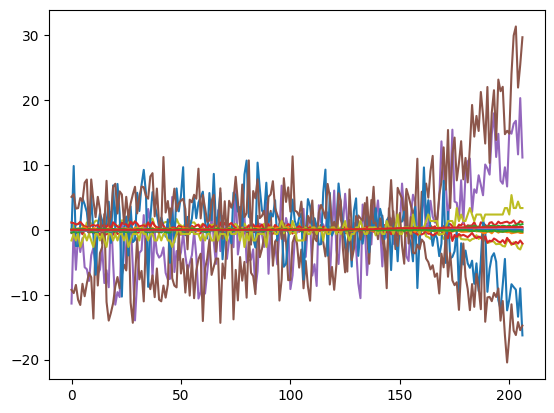

In [73]:
plt.plot(xs[i])
plt.plot(detectors[0].predict(xs[i]))
# plt.plot(input_rs[i].T - np.mean(input_rs[i].T, 0, keepdims=True))

In [35]:
# Run significance tests
from lifelines.fitters.coxph_fitter import CoxPHFitter
import pandas as pd
import json

for detector, stats in separated_output.items():
    times_1 = np.asarray([stat["Delay"] for stat in stats["generic"]])
    times_2 = np.asarray([stat["Delay"] for stat in stats["rs"]])

    events_1 = ~np.isnan(times_1)
    events_2 = ~np.isnan(times_2)
    
    df = pd.DataFrame({
        'time': np.concatenate([times_1, times_2]),
        'event': np.concatenate([events_1, events_2]),
        'group': np.concatenate([np.ones(len(times_1)), np.zeros(len(times_2))])
    })
        
    cph = CoxPHFitter()
    cph.fit(df, duration_col='time', event_col='event', formula="group")
    separated_output[detector]["hr"] = float(cph.summary["exp(coef)"])
    separated_output[detector]["p"] = float(cph.summary["p"])

with open("cmapss_results.json", "w") as f:
    json.dump(separated_output, f)

OSError: [Errno 22] Invalid argument: 'cmapss_results.json'

In [ ]:
plt.plot(prediction)
plt.show()
plt.plot(r_prediction)

plt.show()

In [ ]:
import importlib
importlib.reload(added_metrics)

In [37]:
separated_output

{'ADWIN,clock:1,delta:0.5': {'generic': [{'F1_Score': np.float64(0.9873417721518987),
    'Precision': np.float64(0.975),
    'Recall': np.float64(1.0),
    'Delay': np.float64(0.0),
    'EarlyDetect': np.float64(1.0),
    'TAUC-step': np.float64(0.7798031396446392),
    'TAUC-trapez': 0.6419801257870396,
    'SoftTAUC': np.float64(0.9995501574448943),
    'AUC': 0.9997750787224472},
   {'F1_Score': np.float64(0.9754098360655737),
    'Precision': np.float64(0.952),
    'Recall': np.float64(1.0),
    'Delay': np.float64(0.0),
    'EarlyDetect': np.float64(5.0),
    'TAUC-step': np.float64(0.7062268101163218),
    'TAUC-trapez': 0.6307620529164031,
    'SoftTAUC': np.float64(0.9948979591836735),
    'AUC': 0.9974489795918366},
   {'F1_Score': np.float64(0.9625),
    'Precision': np.float64(0.927710843373494),
    'Recall': np.float64(1.0),
    'Delay': np.float64(0.0),
    'EarlyDetect': np.float64(5.0),
    'TAUC-step': np.float64(0.6970155377404355),
    'TAUC-trapez': 0.6370500225611